# Análisis de Datos e Inferencia Estadística
## Proyecto: Desigualdades en el acceso a hospitalización compleja

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import scipy.stats as stats

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

### Análisis Exploratorio Inicial (EDA)
Antes de responder a las preguntas de investigación, realizaremos una exploración de los datos de alta complejidad para identificar valores ausentes, comprender la distribución base de las variables y detectar *outliers* (valores atípicos) que requieran tratamiento.

In [2]:
# 1. CARGA Y ESTANDARIZACIÓN INICIAL
df = pd.read_csv('indicadores_rem20_20260225.csv', sep=';', encoding='utf-8')

# Estandarizar texto inmediatamente para poder filtrar correctamente
def limpiar_texto(texto):
    if pd.isna(texto): return texto
    return ''.join(c for c in unicodedata.normalize('NFD', str(texto).upper()) if unicodedata.category(c) != 'Mn').strip()

for col in ['GLOSA_SSS', 'ESTABLECIMIENTO', 'AREA_FUNCIONAL']:
    df[col] = df[col].apply(limpiar_texto)

cols_num = ['MES', 'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES', 'INDICE_OCUPACIONAL', 'TRASLADOS', 'NUMERO_EGRESOS', 'LETALIDAD', 'DIAS_ESTADA']
for c in cols_num:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.'), errors='coerce')

In [ ]:
# 2. SELECCIÓN DE DATOS DE ESTUDIO (Alta Complejidad)
df_compleja = df[df['AREA_FUNCIONAL'].str.contains('INTENSIVO|INTERMEDIO|CRITICO', na=False)].copy()

print("--- REPORTE DE VALORES AUSENTES ---")
print(df_compleja[['INDICE_OCUPACIONAL', 'LETALIDAD', 'DIAS_ESTADA', 'TRASLADOS', 'NUMERO_EGRESOS']].isnull().sum())
df_compleja.fillna(0, inplace=True)

print("\n--- ESTADÍSTICAS DESCRIPTIVAS BASE ---")
stats_desc = df_compleja[['INDICE_OCUPACIONAL', 'LETALIDAD', 'DIAS_ESTADA', 'TRASLADOS', 'NUMERO_EGRESOS']].describe().T
stats_desc = stats_desc[['mean', '50%', 'std', '25%', '75%', 'max']]
stats_desc.columns = ['Media', 'Mediana', 'Desv_Estándar', 'Percentil_25', 'Percentil_75', 'Máximo']
display(stats_desc.round(2))

--- REPORTE DE VALORES AUSENTES ---
INDICE_OCUPACIONAL    0
LETALIDAD             0
DIAS_ESTADA           0
TRASLADOS             0
NUMERO_EGRESOS        0
dtype: int64

--- ESTADÍSTICAS DESCRIPTIVAS BASE ---


,Media,Mediana,Desv_Estándar,Percentil_25,Percentil_75,Máximo
INDICE_OCUPACIONAL,76.23,82.66,22.36,65.64,92.14,1275.0
LETALIDAD,25.18,9.38,31.75,0.00,47.62,100.0
DIAS_ESTADA,312.51,186.00,358.26,84.00,415.00,6446.0
TRASLADOS,34.25,19.00,43.35,9.00,40.00,481.0
NUMERO_EGRESOS,16.34,9.00,21.69,4.00,21.00,316.0


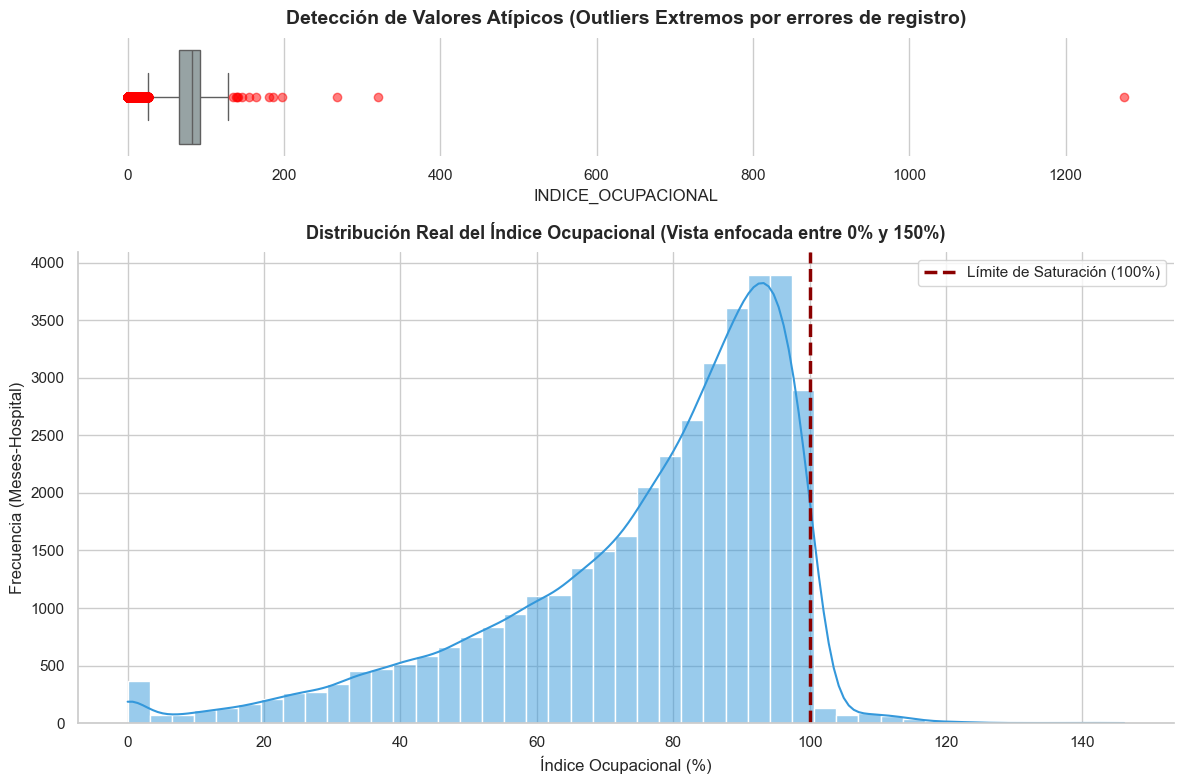

In [ ]:
# 3. EDA: VISUALIZACIÓN DE DISTRIBUCIÓN Y OUTLIERS
# Crear una figura con dos subgráficos apilados (Boxplot arriba, Histograma abajo)
# El ratio 1:4 hace que el histograma sea el protagonista
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": (.2, .8)})

# 1. Gráfico Superior (Boxplot): Mostramos el dataset CRUDO para evidenciar los Outliers
# Destacamos los outliers en color rojo para que resalten en la presentación
sns.boxplot(x=df_compleja['INDICE_OCUPACIONAL'], ax=axes[0], color='#95a5a6', 
            flierprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5})

axes[0].set_title('Detección de Valores Atípicos (Outliers Extremos por errores de registro)', 
                  fontsize=14, fontweight='bold', pad=10)

# 2. Gráfico Inferior (Histograma): Mostramos la distribución lógica (Zoom entre 0 y 150%)
# Filtramos visualmente para que se aprecie la campana y la concentración de datos
datos_logicos = df_compleja[df_compleja['INDICE_OCUPACIONAL'] <= 150]

sns.histplot(data=datos_logicos, x='INDICE_OCUPACIONAL', bins=45, kde=True, color='#3498db', ax=axes[1], edgecolor='white')

axes[1].set_title('Distribución Real del Índice Ocupacional (Vista enfocada entre 0% y 150%)', 
                  fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Índice Ocupacional (%)', fontsize=12)
axes[1].set_ylabel('Frecuencia (Meses-Hospital)', fontsize=12)

# Añadimos una línea crítica para marcar el colapso del 100%
axes[1].axvline(100, color='darkred', linestyle='--', linewidth=2.5, label='Límite de Saturación (100%)')
axes[1].legend(loc='upper right', fontsize=11)

# Ajustes de limpieza visual
sns.despine(ax=axes[0], left=True, bottom=True)
sns.despine(ax=axes[1])
plt.tight_layout()

plt.show()

### Resolución de Preguntas de Investigación (Estimación Estadística)

### Pregunta 1: ¿Existen diferencias regionales en el acceso a hospitalizaciones de alta complejidad?
**Estrategia de defensa:** No solo mostraremos el total, sino la media mensual, la desviación estándar (para medir la inestabilidad del acceso) y el máximo de días cama ocupadas por región para dimensionar la brecha real entre los extremos del país.

EVIDENCIA PARA DEFENSA Q1 - Brecha de Acceso Regional:


,Servicio_de_Salud,Total_Acceso_Anual,Media_Mensual,Desv_Estandar,Max_Mensual,Min_Mensual,Peso_Nacional (%)
22,METROPOLITANO ORIENTE,1088662,441.1,323.2,2030,2,8.3
24,METROPOLITANO SUR ORIENTE,1067297,397.4,491.1,3204,0,8.1
21,METROPOLITANO OCCIDENTE,1040756,433.8,425.0,4472,0,7.9
23,METROPOLITANO SUR,971580,409.3,394.2,3226,0,7.4
19,METROPOLITANO CENTRAL,923575,459.9,464.8,2663,0,7.0


,Servicio_de_Salud,Total_Acceso_Anual,Media_Mensual,Desv_Estandar,Max_Mensual,Min_Mensual,Peso_Nacional (%)
28,TARAPACA,106426,359.5,232.2,860,18,0.8
17,LOS RIOS,83587,387.0,383.9,1417,31,0.6
1,AISEN,72248,124.8,55.9,259,0,0.5
7,ARICA Y PARINACOTA,45797,212.0,205.4,741,1,0.3
5,ARAUCO,23009,111.2,50.7,279,0,0.2


C:\Users\hermo\AppData\Local\Temp\ipykernel_19632\609908144.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_compleja,


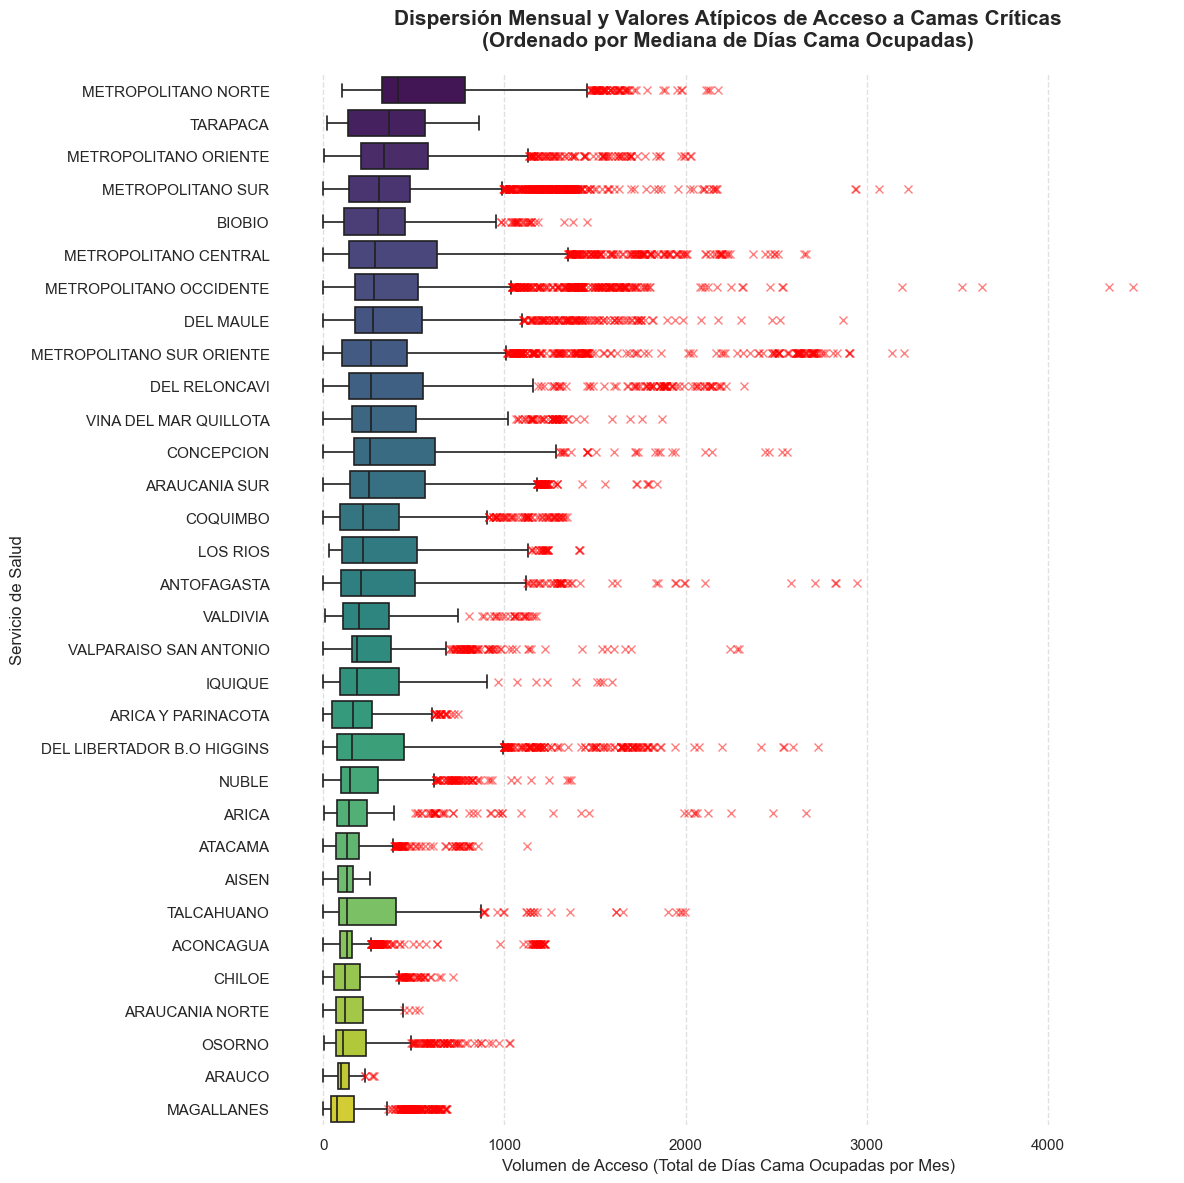

In [ ]:
# Análisis de acceso con múltiples estimadores estadísticos
acceso_stats = df_compleja.groupby('GLOSA_SSS')['DIAS_CAMAS_OCUPADAS'].agg(['sum', 'mean', 'std', 'max', 'min']).reset_index()
acceso_stats.columns = ['Servicio_de_Salud', 'Total_Acceso_Anual', 'Media_Mensual', 'Desv_Estandar', 'Max_Mensual', 'Min_Mensual']
acceso_stats = acceso_stats.sort_values('Total_Acceso_Anual', ascending=False)

# Calcular el peso porcentual de cada región sobre el total nacional
total_nacional = acceso_stats['Total_Acceso_Anual'].sum()
acceso_stats['Peso_Nacional (%)'] = (acceso_stats['Total_Acceso_Anual'] / total_nacional) * 100

print("EVIDENCIA PARA DEFENSA Q1 - Brecha de Acceso Regional:")
display(acceso_stats.head(5).round(1)) # Top 5 con más acceso
display(acceso_stats.tail(5).round(1)) # Top 5 con menos acceso

# 1. Ordenaremos de mayor a menor según la mediana de acceso
orden_regiones = df_compleja.groupby('GLOSA_SSS')['DIAS_CAMAS_OCUPADAS'].median().sort_values(ascending=False).index

# 2. Crear la figura
plt.figure(figsize=(12, 12)) 

# 3. Boxplot Horizontal
# Cambiamos x por y. Añadimos el orden calculado.
# Resaltamos los outliers (fliers) con una 'x' roja transparente para evidenciar los meses atípicos de alta demanda.
ax = sns.boxplot(data=df_compleja, 
                 x='DIAS_CAMAS_OCUPADAS', 
                 y='GLOSA_SSS', 
                 order=orden_regiones, 
                 palette='viridis', 
                 linewidth=1.2,
                 flierprops={"marker": "x", "markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5})

# 4. Estética
plt.title('Dispersión Mensual y Valores Atípicos de Acceso a Camas Críticas\n(Ordenado por Mediana de Días Cama Ocupadas)', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Volumen de Acceso (Total de Días Cama Ocupadas por Mes)', fontsize=12)
plt.ylabel('Servicio de Salud', fontsize=12)

# Añadir una linea sutil en el eje X para facilitar la lectura de los valores
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

# Limpiar bordes innecesarios
sns.despine(left=True, bottom=True)
plt.tight_layout()

# plt.xscale('log')

plt.show()

### Pregunta 2: ¿Las regiones con menor disponibilidad hospitalaria presentan menor proporción de camas complejas?
**Estrategia de defensa:** Calcularemos el **Coeficiente de Correlación de Pearson** para demostrar matemáticamente si existe una relación lineal directa. Un coeficiente positivo validará estadísticamente la hipótesis.

EVIDENCIA PARA DEFENSA Q2 - Relación Matemática:
Coeficiente de Correlación (r): 0.329
P-valor: 0.0663 (Si es < 0.05, la relación es estadísticamente significativa)

Regiones más castigadas (Baja disponibilidad total y baja proporción compleja):


,GLOSA_SSS,TOTAL_CAMAS_RED,CAMAS_COMPLEJAS,PROPORCION_COMPLEJA (%)
7,ARICA Y PARINACOTA,286825,45797,15.97
28,TARAPACA,463606,106426,22.96
1,AISEN,670882,72248,10.77
17,LOS RIOS,760300,83587,10.99
10,CHILOE,782653,116820,14.93


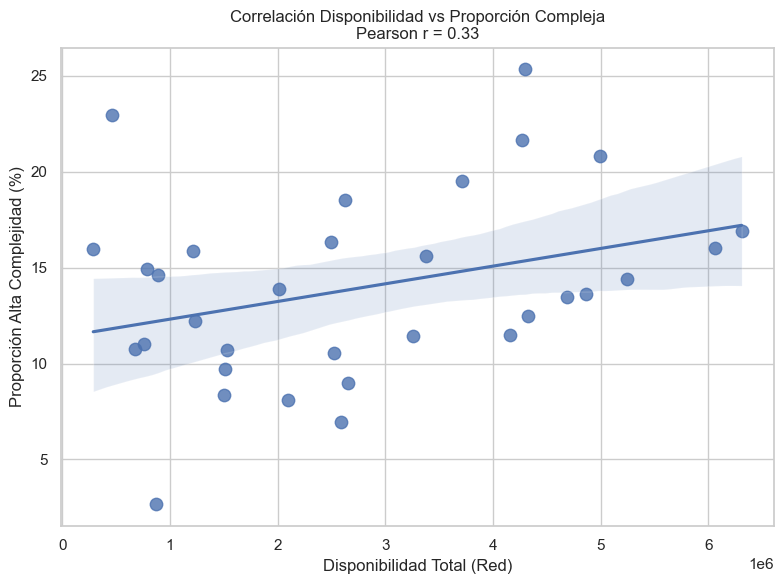

In [6]:
total_regional = df.groupby('GLOSA_SSS')['DIAS_CAMAS_OCUPADAS'].sum().reset_index().rename(columns={'DIAS_CAMAS_OCUPADAS': 'TOTAL_CAMAS_RED'})
complejas_regional = df_compleja.groupby('GLOSA_SSS')['DIAS_CAMAS_OCUPADAS'].sum().reset_index().rename(columns={'DIAS_CAMAS_OCUPADAS': 'CAMAS_COMPLEJAS'})

analisis_prop = pd.merge(total_regional, complejas_regional, on='GLOSA_SSS', how='left').fillna(0)
analisis_prop['PROPORCION_COMPLEJA (%)'] = (analisis_prop['CAMAS_COMPLEJAS'] / analisis_prop['TOTAL_CAMAS_RED']) * 100

# Prueba estadística formal: Correlación de Pearson
correlacion, p_valor = stats.pearsonr(analisis_prop['TOTAL_CAMAS_RED'], analisis_prop['PROPORCION_COMPLEJA (%)'])

print("EVIDENCIA PARA DEFENSA Q2 - Relación Matemática:")
print(f"Coeficiente de Correlación (r): {correlacion:.3f}")
print(f"P-valor: {p_valor:.4f} (Si es < 0.05, la relación es estadísticamente significativa)")
print("\nRegiones más castigadas (Baja disponibilidad total y baja proporción compleja):")
display(analisis_prop.sort_values('TOTAL_CAMAS_RED').head(5).round(2))

plt.figure(figsize=(8, 6))
sns.regplot(data=analisis_prop, x='TOTAL_CAMAS_RED', y='PROPORCION_COMPLEJA (%)', scatter_kws={'s':80})
plt.title(f'Correlación Disponibilidad vs Proporción Compleja\nPearson r = {correlacion:.2f}')
plt.xlabel('Disponibilidad Total (Red)')
plt.ylabel('Proporción Alta Complejidad (%)')
plt.show()

### Pregunta 3: ¿La distribución de pacientes se concentra en ciertos hospitales?
**Estrategia de defensa:** Analizaremos los cuartiles. Demostraremos qué porcentaje exacto de los hospitales (ej. el 10% superior) absorbe la mayor carga de la red pública, dando números contundentes de concentración.

In [7]:
hosp_concentracion = df_compleja.groupby('ESTABLECIMIENTO')['DIAS_CAMAS_OCUPADAS'].sum().sort_values(ascending=False).reset_index()
total_camas_pais = hosp_concentracion['DIAS_CAMAS_OCUPADAS'].sum()
total_hospitales = len(hosp_concentracion)

hosp_concentracion['PORCENTAJE'] = (hosp_concentracion['DIAS_CAMAS_OCUPADAS'] / total_camas_pais) * 100
hosp_concentracion['ACUMULADO (%)'] = hosp_concentracion['PORCENTAJE'].cumsum()

# Extraer métricas duras para la defensa
top_10_percent_count = int(total_hospitales * 0.10)
carga_top_10 = hosp_concentracion.head(top_10_percent_count)['PORCENTAJE'].sum()

print("EVIDENCIA PARA DEFENSA Q3 - Concentración en la Red:")
print(f"La red de alta complejidad está compuesta por {total_hospitales} establecimientos.")
print(f"Solo el 10% de los recintos ({top_10_percent_count} hospitales) concentra el {carga_top_10:.1f}% de todas las hospitalizaciones del país.")

print("\nLos 5 Hospitales Pilares del Sistema:")
display(hosp_concentracion[['ESTABLECIMIENTO', 'DIAS_CAMAS_OCUPADAS', 'PORCENTAJE', 'ACUMULADO (%)']].head(5).round(2))

EVIDENCIA PARA DEFENSA Q3 - Concentración en la Red:
La red de alta complejidad está compuesta por 139 establecimientos.
Solo el 10% de los recintos (13 hospitales) concentra el 39.2% de todas las hospitalizaciones del país.

Los 5 Hospitales Pilares del Sistema:


,ESTABLECIMIENTO,DIAS_CAMAS_OCUPADAS,PORCENTAJE,ACUMULADO (%)
0,"HOSPITAL SAN JUAN DE DIOS (SANTIAGO, SANTIAGO)",525223,3.99,3.99
1,COMPLEJO HOSPITALARIO DR. SOTERO DEL RIO (SANT...,504579,3.83,7.82
2,"HOSPITAL BARROS LUCO TRUDEAU (SANTIAGO, SAN MI...",478819,3.64,11.46
3,HOSPITAL REGIONAL DE RANCAGUA,443069,3.36,14.82
4,"COMPLEJO HOSPITALARIO SAN JOSE (SANTIAGO, INDE...",438427,3.33,18.15


### Pregunta 4: Colapso en Invierno y Velocidad de Saturación
**Estrategia de defensa:** Calcularemos el "Delta de Estrés" (cuánto aumenta la saturación en invierno vs el resto del año). Además, observaremos el máximo índice ocupacional tocado por cada región en los meses críticos para demostrar riesgo de quiebre de stock de camas.

EVIDENCIA PARA DEFENSA Q4 - Impacto del Invierno:
Regiones con el mayor salto de ocupación al llegar el invierno (Riesgo de colapso rápido):


,Media_Resto,Media_Invierno,Delta_Estres (Aumento %),Max_Invierno
GLOSA_SSS,,,,
METROPOLITANO SUR ORIENTE,74.6,80.6,6.1,103.2
VALDIVIA,80.2,86.1,5.9,115.8
NUBLE,66.3,71.3,5.0,113.9
AISEN,58.2,63.0,4.8,140.9
ACONCAGUA,67.9,72.6,4.8,100.0
METROPOLITANO CENTRAL,82.2,86.5,4.3,140.0
LOS RIOS,76.7,80.8,4.1,112.8
ANTOFAGASTA,71.7,75.8,4.1,100.0


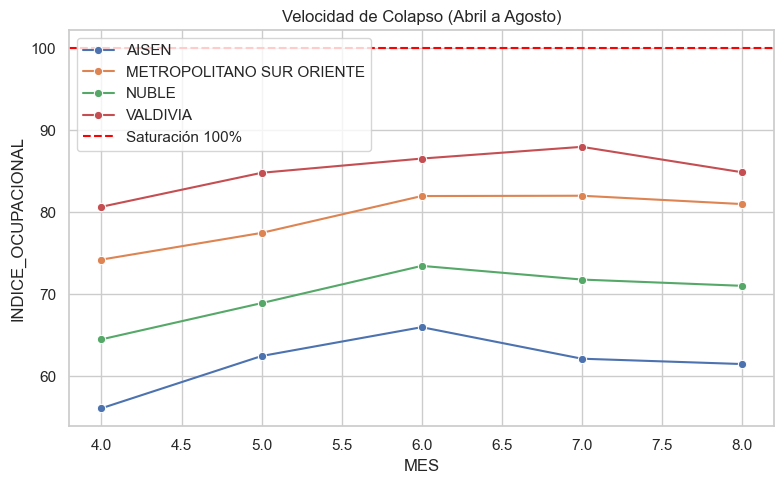

In [8]:
df_compleja['ESTACION'] = np.where(df_compleja['MES'].isin([5, 6, 7, 8]), 'INVIERNO', 'RESTO')

# Comparación de medias y varianzas
invierno_stats = df_compleja.groupby(['GLOSA_SSS', 'ESTACION'])['INDICE_OCUPACIONAL'].agg(['mean', 'max']).unstack()
invierno_stats.columns = ['Media_Invierno', 'Media_Resto', 'Max_Invierno', 'Max_Resto']
invierno_stats['Delta_Estres (Aumento %)'] = invierno_stats['Media_Invierno'] - invierno_stats['Media_Resto']
invierno_stats = invierno_stats.sort_values('Delta_Estres (Aumento %)', ascending=False).dropna()

print("EVIDENCIA PARA DEFENSA Q4 - Impacto del Invierno:")
print("Regiones con el mayor salto de ocupación al llegar el invierno (Riesgo de colapso rápido):")
display(invierno_stats[['Media_Resto', 'Media_Invierno', 'Delta_Estres (Aumento %)', 'Max_Invierno']].head(8).round(1))

# Gráfico de la evolución mensual de las 4 más estresadas
top_4_estres = invierno_stats.head(4).index
evolucion = df_compleja[df_compleja['GLOSA_SSS'].isin(top_4_estres) & df_compleja['MES'].isin([4,5,6,7,8])].groupby(['GLOSA_SSS', 'MES'])['INDICE_OCUPACIONAL'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=evolucion, x='MES', y='INDICE_OCUPACIONAL', hue='GLOSA_SSS', marker='o')
plt.axhline(100, color='red', linestyle='--', label='Saturación 100%')
plt.title('Velocidad de Colapso (Abril a Agosto)')
plt.legend()
plt.show()

### Pregunta 5: Capacidad Resolutiva (Traslados vs Egresos) - PREGUNTA PRINCIPAL
**Estrategia de defensa:** Esta es la pregunta clave. Además de la proporción, calcularemos el volumen absoluto de traslados y cruzaremos esta información con el *Promedio de Días de Estada*. Un recinto con altos traslados y bajos días de estada confirma empíricamente que funciona como "puente" y estabilizador, despachando al paciente rápidamente a otro recinto.

EVIDENCIA PARA DEFENSA Q5 - Falla en Capacidad Resolutiva:
Se identificaron 123 hospitales que trasladan a MÁS de la mitad de sus pacientes complejos.
Detalle de los recintos que actúan como estabilizadores (Top 10):


,ESTABLECIMIENTO,TOTAL_SALIDAS,TRASLADOS,TASA_TRASLADOS (%),DIAS_ESTADA,INDICE_OCUPACIONAL
136,INSTITUTO PSIQUIATRICO DR. JOSE HORWITZ BARAK ...,9825,9485,96.5,271.8,69.8
138,INSTITUTO TRAUMATOLOGICO DR. TEODORO GEBAUER,7587,7254,95.6,66.2,50.6
137,INSTITUTO TRAUMATOLOGICO DR TEODORO GEBAUER,2884,2645,91.7,88.6,49.2
135,INSTITUTO NACIONAL DEL CANCER DR. CAUPOLICAN P...,5264,4743,90.1,172.0,90.6
134,INSTITUTO NACIONAL DEL CANCER DR CAUPOLICAN PA...,1671,1502,89.9,164.4,79.8
79,HOSPITAL DR. EDUARDO PEREIRA RAMIREZ (VALPARAISO),9301,8127,87.4,253.3,91.6
129,HOSPITAL TRAUMATOLOGICO (CONCEPCION),5501,4782,86.9,140.7,71.4
62,HOSPITAL DR EXEQUIEL GONZALEZ CORTES (SANTIAGO...,4075,3513,86.2,246.5,82.2
52,HOSPITAL DE VILLARRICA,957,820,85.7,124.2,88.6
81,HOSPITAL DR. EXEQUIEL GONZALEZ CORTES (SANTIAG...,14497,12100,83.5,148.5,76.2


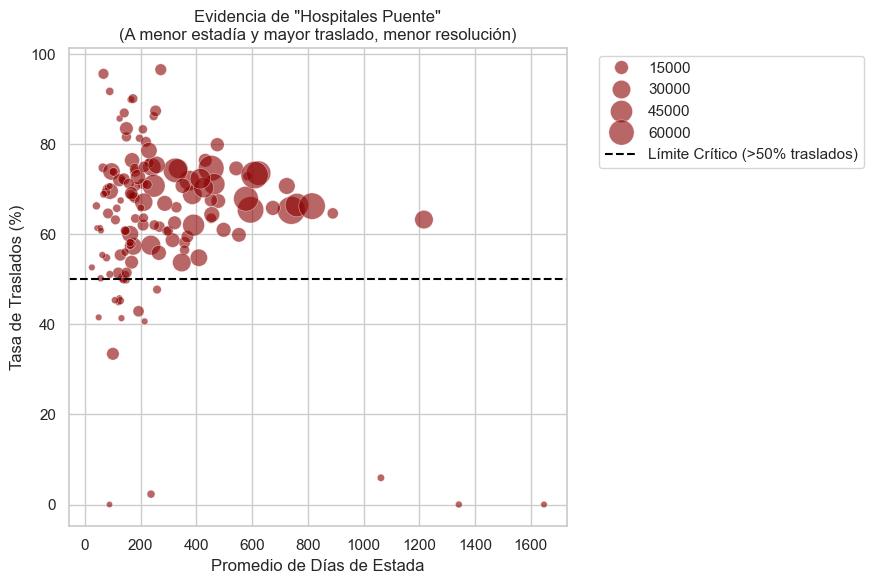

In [9]:
# Análisis multivariable de capacidad resolutiva
resol_hosp = df_compleja.groupby('ESTABLECIMIENTO').agg({
    'TRASLADOS': 'sum',
    'NUMERO_EGRESOS': 'sum',
    'DIAS_ESTADA': 'mean', # Promedio de estadía
    'INDICE_OCUPACIONAL': 'mean'
}).reset_index()

resol_hosp['TOTAL_SALIDAS'] = resol_hosp['TRASLADOS'] + resol_hosp['NUMERO_EGRESOS']
resol_hosp = resol_hosp[resol_hosp['TOTAL_SALIDAS'] >= 20].copy() # Filtro de validez estadística
resol_hosp['TASA_TRASLADOS (%)'] = (resol_hosp['TRASLADOS'] / resol_hosp['TOTAL_SALIDAS']) * 100

criticos = resol_hosp[resol_hosp['TASA_TRASLADOS (%)'] > 50].sort_values('TASA_TRASLADOS (%)', ascending=False)

print("EVIDENCIA PARA DEFENSA Q5 - Falla en Capacidad Resolutiva:")
print(f"Se identificaron {len(criticos)} hospitales que trasladan a MÁS de la mitad de sus pacientes complejos.")
print("Detalle de los recintos que actúan como estabilizadores (Top 10):")
display(criticos[['ESTABLECIMIENTO', 'TOTAL_SALIDAS', 'TRASLADOS', 'TASA_TRASLADOS (%)', 'DIAS_ESTADA', 'INDICE_OCUPACIONAL']].round(1).head(10))

# Dispersión cruzando Traslados vs Días de Estada
plt.figure(figsize=(9, 6))
sns.scatterplot(data=resol_hosp, x='DIAS_ESTADA', y='TASA_TRASLADOS (%)', size='TOTAL_SALIDAS', sizes=(20, 400), alpha=0.6, color='darkred')
plt.axhline(50, color='black', linestyle='--', label='Límite Crítico (>50% traslados)')
plt.title('Evidencia de "Hospitales Puente"\n(A menor estadía y mayor traslado, menor resolución)')
plt.xlabel('Promedio de Días de Estada')
plt.ylabel('Tasa de Traslados (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

---
### Análisis Visual Comparativo Avanzado
Para profundizar en las desigualdades del sistema y preparar la defensa del proyecto, utilizaremos visualizaciones multivariables. Estas nos permitirán contrastar el colapso temporal (mapa de calor), los desenlaces clínicos de los pacientes (barras apiladas al 100%) y la eficiencia hospitalaria (gráfico de violín).

#### A. Mapa de Calor (Heatmap) del Colapso Mensual
Este gráfico nos permite visualizar simultáneamente a todos los Servicios de Salud. Las zonas más rojas indicarán los focos de saturación crítica a lo largo del año.

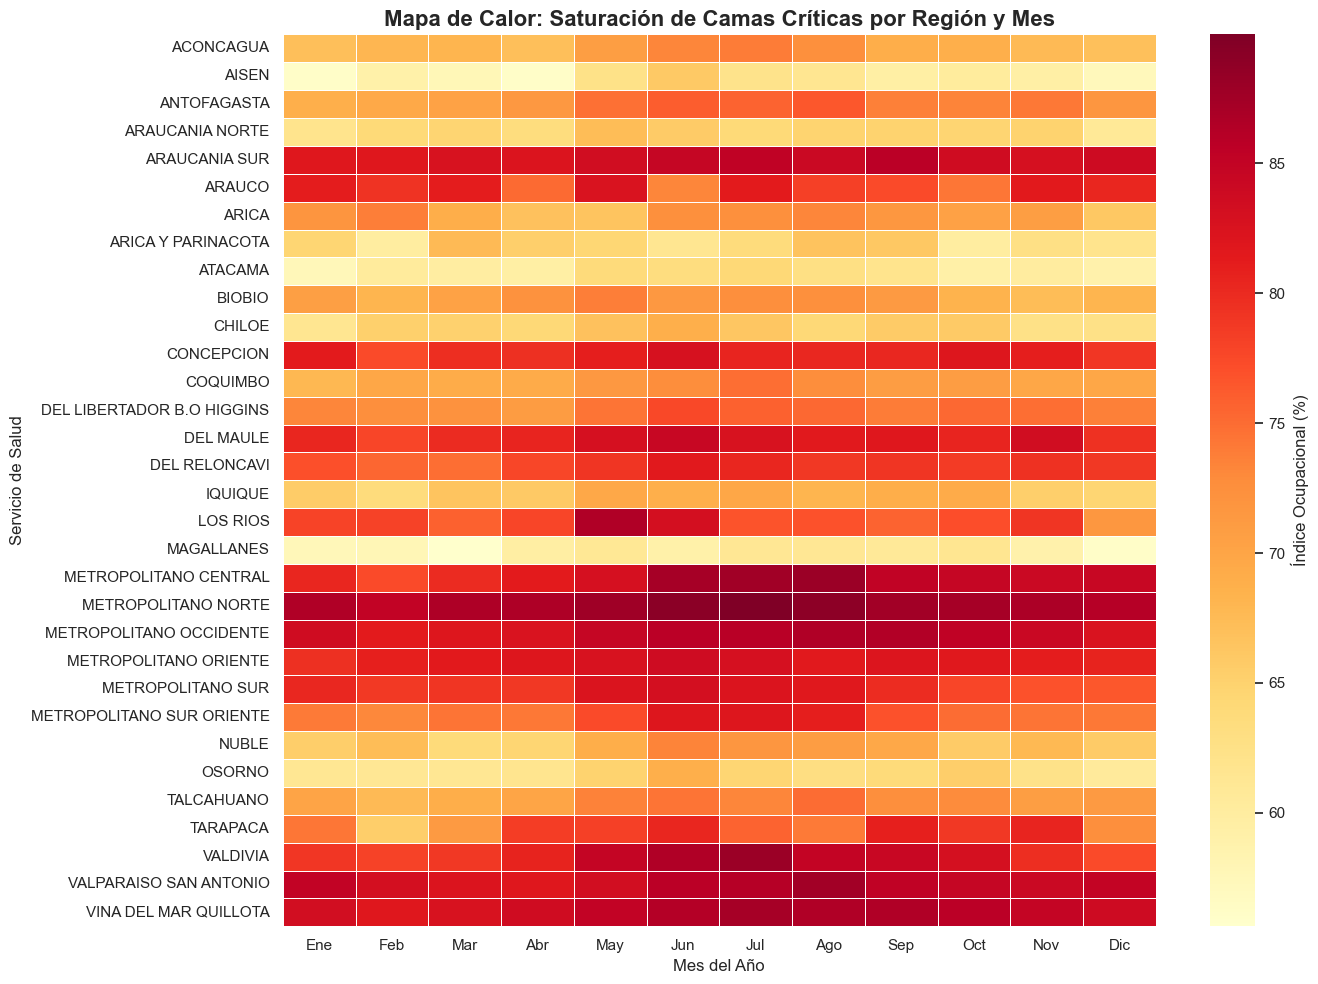

In [10]:
# Creamos una matriz pivotando Regiones vs Meses
heatmap_data = df_compleja.groupby(['GLOSA_SSS', 'MES'])['INDICE_OCUPACIONAL'].mean().unstack()

plt.figure(figsize=(14, 10))
# Utilizamos un mapa de colores donde amarillo es holgura y rojo oscuro es colapso
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, linewidths=.5, cbar_kws={'label': 'Índice Ocupacional (%)'})

plt.title('Mapa de Calor: Saturación de Camas Críticas por Región y Mes', fontsize=16, fontweight='bold')
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Servicio de Salud', fontsize=12)
plt.xticks(np.arange(12) + 0.5, ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=0)
plt.show()

#### B. Composición de Desenlaces Clínicos
¿Qué ocurre realmente con los pacientes que ingresan a camas de alta complejidad? Descompondremos el total de salidas clínicas en tres categorías: Egresos Vivos (Verde), Traslados a otros recintos (Amarillo) y Egresos Fallecidos (Gris oscuro).

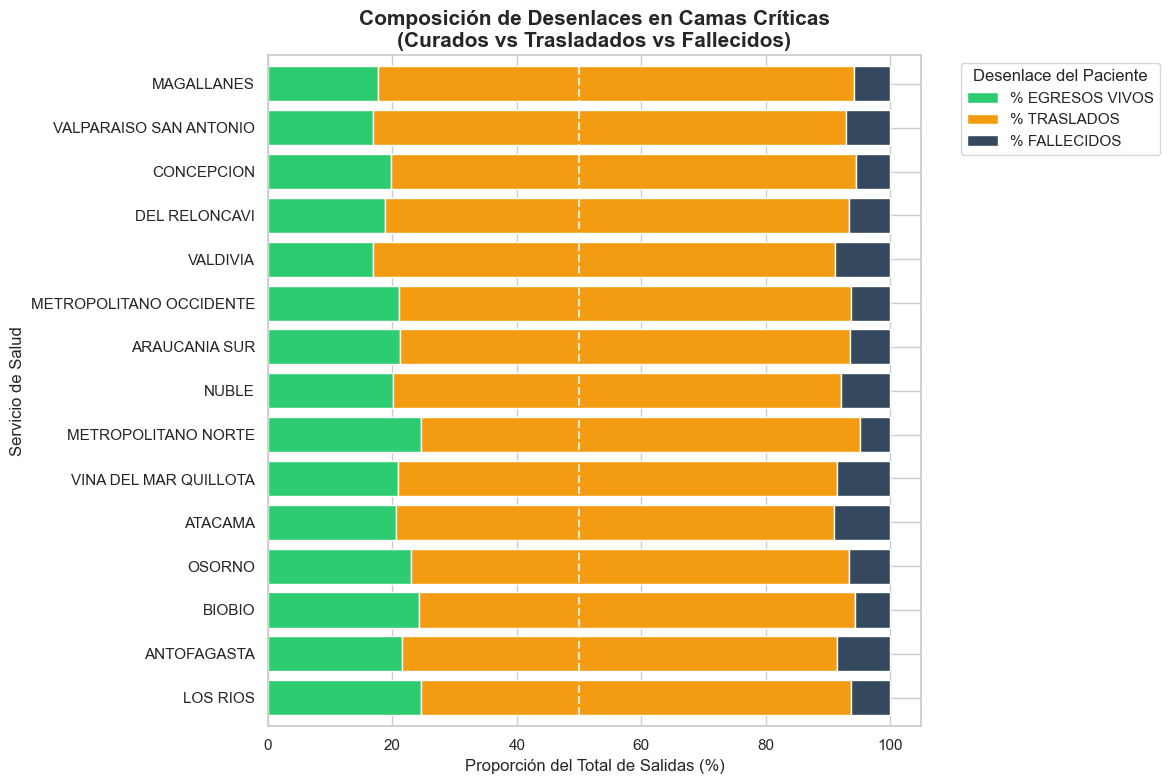

In [11]:
# Sumar los diferentes tipos de salidas
outcomes = df_compleja.groupby('GLOSA_SSS')[['NUMERO_EGRESOS', 'TRASLADOS', 'EGRESOS_FALLECIDOS']].sum().reset_index()

# Calculamos Egresos Vivos (Egresos totales - Fallecidos)
outcomes['EGRESOS_VIVOS'] = outcomes['NUMERO_EGRESOS'] - outcomes['EGRESOS_FALLECIDOS']
outcomes['TOTAL_SALIDAS'] = outcomes['EGRESOS_VIVOS'] + outcomes['TRASLADOS'] + outcomes['EGRESOS_FALLECIDOS']

# Filtramos zonas con muy pocos datos para no sesgar
outcomes = outcomes[outcomes['TOTAL_SALIDAS'] > 100].copy()

# Convertimos todo a porcentaje del 100%
outcomes['% EGRESOS VIVOS'] = (outcomes['EGRESOS_VIVOS'] / outcomes['TOTAL_SALIDAS']) * 100
outcomes['% TRASLADOS'] = (outcomes['TRASLADOS'] / outcomes['TOTAL_SALIDAS']) * 100
outcomes['% FALLECIDOS'] = (outcomes['EGRESOS_FALLECIDOS'] / outcomes['TOTAL_SALIDAS']) * 100

# Ordenamos por los que tienen más traslados (menor resolución)
outcomes = outcomes.sort_values('% TRASLADOS', ascending=True).tail(15)

# Crear gráfico apilado
fig, ax = plt.subplots(figsize=(12, 8))
outcomes.set_index('GLOSA_SSS')[['% EGRESOS VIVOS', '% TRASLADOS', '% FALLECIDOS']].plot(
    kind='barh', stacked=True, color=['#2ecc71', '#f39c12', '#34495e'], ax=ax, width=0.8
)

plt.title('Composición de Desenlaces en Camas Críticas\n(Curados vs Trasladados vs Fallecidos)', fontsize=15, fontweight='bold')
plt.xlabel('Proporción del Total de Salidas (%)', fontsize=12)
plt.ylabel('Servicio de Salud', fontsize=12)
plt.legend(title='Desenlace del Paciente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axvline(50, color='white', linestyle='--', linewidth=1.5, alpha=0.8) # Línea visual a la mitad
plt.show()

#### C. Distribución de Días de Estada (RM vs Regiones)
Finalmente, utilizaremos un Gráfico de Violín para comparar la eficiencia y distribución de los tiempos de estadía entre la Región Metropolitana y el resto de las regiones del país, evaluando si la variabilidad es equitativa.

C:\Users\hermo\AppData\Local\Temp\ipykernel_19632\2236725603.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=datos_violin, x='MACROZONA', y='DIAS_ESTADA', palette=['#3498db', '#e74c3c'], split=False, inner="quartile")


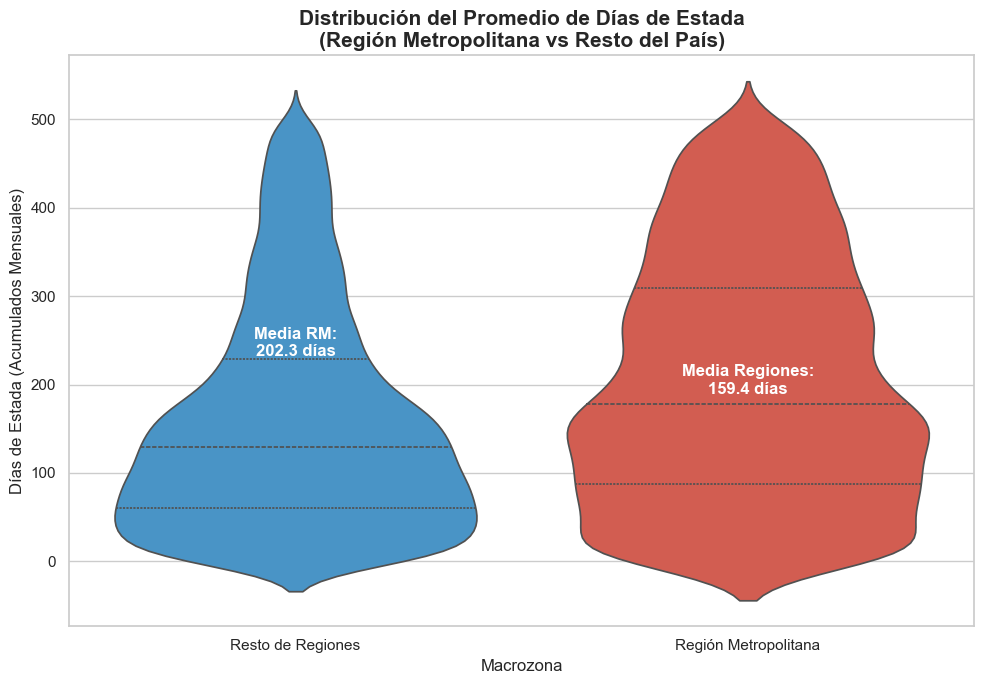

In [12]:
# Clasificamos en dos grandes macrozonas
df_compleja['MACROZONA'] = np.where(df_compleja['GLOSA_SSS'].str.contains('METROPOLITANO'), 'Región Metropolitana', 'Resto de Regiones')

# Quitamos outliers extremos de estadía para que el gráfico sea legible
datos_violin = df_compleja[df_compleja['DIAS_ESTADA'] < 500]

plt.figure(figsize=(10, 7))
sns.violinplot(data=datos_violin, x='MACROZONA', y='DIAS_ESTADA', palette=['#3498db', '#e74c3c'], split=False, inner="quartile")

plt.title('Distribución del Promedio de Días de Estada\n(Región Metropolitana vs Resto del País)', fontsize=15, fontweight='bold')
plt.xlabel('Macrozona', fontsize=12)
plt.ylabel('Días de Estada (Acumulados Mensuales)', fontsize=12)

# Añadimos un texto explicativo de las medias
media_rm = datos_violin[datos_violin['MACROZONA']=='Región Metropolitana']['DIAS_ESTADA'].mean()
media_reg = datos_violin[datos_violin['MACROZONA']=='Resto de Regiones']['DIAS_ESTADA'].mean()
plt.text(0, media_rm + 30, f'Media RM:\n{media_rm:.1f} días', ha='center', color='white', weight='bold')
plt.text(1, media_reg + 30, f'Media Regiones:\n{media_reg:.1f} días', ha='center', color='white', weight='bold')

plt.show()